tutorial source:
https://www.youtube.com/watch?v=JoR5HCs0n0s

In [40]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

(28, 28)

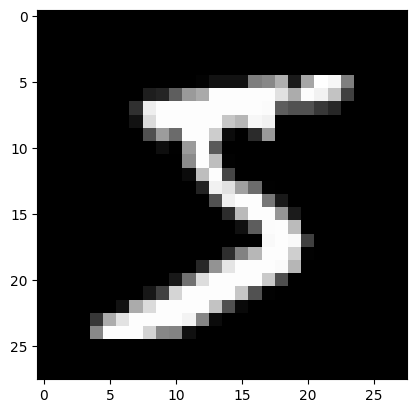

In [41]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
plt.imshow(x_train[0], cmap='gray')
x_train[0].shape

In [42]:
x_train = x_train/255
x_test = x_test/255

In [43]:
encoder_input = keras.Input(shape=(28,28,1), name='img')
x = keras.layers.Flatten()(encoder_input)
encoder_output = keras.layers.Dense(32, activation='relu')(x)


encoder = keras.Model(encoder_input, encoder_output, name='encoder')


decoder_input = keras.layers.Dense(784, activation='relu')(encoder_output)
decoder_output = keras.layers.Reshape((28,28,1))(decoder_input)

opt = keras.optimizers.Adam(learning_rate=0.001, decay= 1e-6)

autoencoder = keras.Model(encoder_input, decoder_output, name='autoencoder')
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ img (InputLayer)                │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 784)            │        25,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,992 (199.19 KB)

 Trainable params: 50,992 (199.19 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
autoencoder.compile(opt, loss='mse')
autoencoder.fit(
    x_train,
    x_train,  # x_train for training and testing. You want input to match output.
    epochs = 3,
    batch_size = 32,
    validation_split=0.1
)

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 726us/step - loss: 0.0332 - val_loss: 0.0161
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 670us/step - loss: 0.0160 - val_loss: 0.0156
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - loss: 0.0157 - val_loss: 0.0156


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


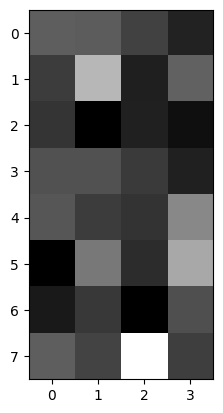

In [45]:
example = encoder.predict([x_test[0].reshape(-1, 28, 28, 1)])[0]
plt.imshow(example.reshape(8,4), cmap='gray')

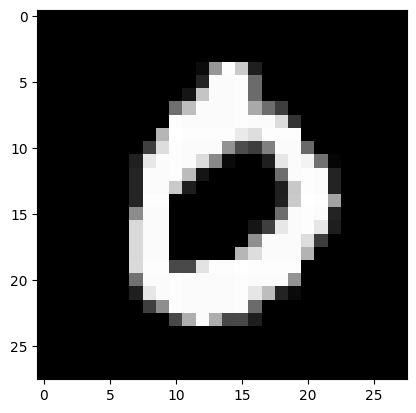

In [46]:
plt.imshow(x_test[3], cmap='gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


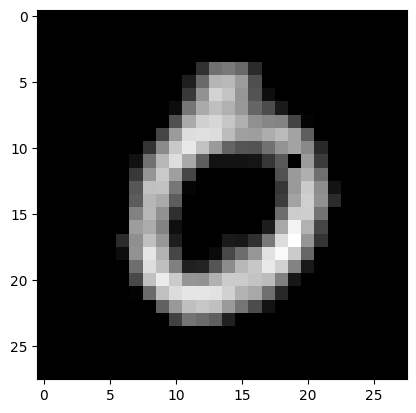

In [47]:
ae_out = autoencoder.predict([x_test[3].reshape(-1, 28, 28, 1)])[0]
plt.imshow(ae_out, cmap='gray')